# Examen - Fundamentos de Data Science
## Análisis de Rotación de Clientes en Telecomunicaciones
Este análisis tiene como objetivo limpiar ,explorar y analizar los datos de rotación
de clientes de una empresa de telecomunicaciones.

## Fuentes utilizadas
- Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
- Asistencia de sintaxis: Claude y Gemini - usado como guía

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Dataset cargado correctamente")


Dataset cargado correctamente


## Exploración Inicial del Dataset
Antes de limpiar los datos, exploramos el contenido del dataset para
entender su estructura, contexto  y detectar posibles problemas.

In [20]:
print(f"El DataFrame tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

El DataFrame tiene 7043 filas y 21 columnas.


In [21]:
print("\nPrimeras 10 filas del DataFrame:")
display(df.head(10))


Primeras 10 filas del DataFrame:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [22]:
print("\nÚltimas 5 filas del DataFrame:")
display(df.tail(5))


Últimas 5 filas del DataFrame:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


### 1.2. Nombres de las Columnas

Es útil tener una lista clara de todos los nombres de las columnas para futuras referencias.

In [23]:
print("Nombres de las columnas:")
for col in df.columns:
    print(col)

Nombres de las columnas:
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


### 2.1. Evaluación Inicial de Tipos de Datos y Estadísticas Resumidas

Se examina los tipos de datos de cada columna oara obtener estadísticas descriptivas para las columnas numéricas. Esto  ayuda a identificar columnas que puedan necesitar limpieza o conversión de tipo de dato, como `TotalCharges`.;)

In [24]:
print("Información general del DataFrame (tipos de datos y valores no nulos):")
df.info()

Información general del DataFrame (tipos de datos y valores no nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          

In [25]:
print("\nEstadísticas descriptivas para columnas numéricas:")
display(df.describe())


Estadísticas descriptivas para columnas numéricas:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### 3.1. Limpieza de la columna `TotalCharges`

Como hemos observado en `df.info()`, la columna `TotalCharges` es de tipo `object` (cadena de texto) en lugar de numérica. Esto se debe a la presencia de cadenas de texto vacías. Se procede a:
1. Reemplazar los valores vacíos con `NaN` (Not a Number).
2. Convertir la columna a un tipo de dato numérico (float).

In [26]:
# Identificar filas con valores problemáticos en TotalCharges
print("Valores únicos problemáticos en TotalCharges antes de la limpieza:")
print(df[df['TotalCharges'].str.strip() == ''].shape[0], "filas con espacios vacíos")

# Reemplazar los espacios vacíos en 'TotalCharges' con NaN y convertir a tipo numérico
df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Verificar el número de valores nulos después de la conversión
print(f"\nNúmero de valores nulos en TotalCharges después de la limpieza: {df['TotalCharges'].isnull().sum()}")

# Confirmar el nuevo tipo de dato de la columna 'TotalCharges'
print("\nTipo de dato de TotalCharges después de la conversión:")
df.info()

Valores únicos problemáticos en TotalCharges antes de la limpieza:
11 filas con espacios vacíos

Número de valores nulos en TotalCharges después de la limpieza: 11

Tipo de dato de TotalCharges después de la conversión:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSuppor

## ¿De qué trata el dataset?
Este dataset contiene información sobre 7043 clientes de una empresa de
telecomunicaciones. Tiene 21 columnas que describen:

- Información del cliente: género, si es adulto mayor, si tiene pareja, dependientes
- Servicios contratados: teléfono, internet, seguridad, respaldo, soporte técnico
- Información del contrato: tipo de contrato, facturación, método de pago
- Cargos: cargos mensuales y cargos totales
- Churn: si el cliente abandonó o no la empresa

## Problemas detectados en la exploración inicial
- TotalCharges es texto (object) cuando debería ser número (float64)
- TotalCharges tiene 11 valores faltantes
- SeniorCitizen tiene valores 0 y 1 en vez de Yes/No
- tenure tiene valores mínimos de 0

## Limpieza de Datos
### Paso 1: Duplicados

In [28]:
# Verificar duplicados
print(f"Número de filas duplicadas: {df.duplicated().sum()}")

Número de filas duplicadas: 0


### Paso 2: Valores Nulos
Verificamos valores nulos con isnull() y también espacios vacíos
que no son detectados como nulos técnicos.

In [31]:
# Verificar valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())

# Filas con valores nulos
print("\nFilas con valores nulos en TotalCharges:")
display(df[df['TotalCharges'].isnull()])


Valores nulos por columna:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Filas con valores nulos en TotalCharges:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


### Paso 2: Valores Nulos
Decisión: Los 11 valores nulos en TotalCharges corresponden a clientes
con tenure = 0, es decir clientes nuevos sin historial de pagos.
Se rellenan con 0.0 ya que es el valor lógico para este caso.

In [32]:
# Rellenar valores nulos en TotalCharges con 0.0
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

print("Valores nulos restantes en TotalCharges:", df['TotalCharges'].isnull().sum())

Valores nulos restantes en TotalCharges: 0


### Paso 3: Tipos de Datos
Se identificaron dos problemas:
1. TotalCharges está como texto (object) y debe ser número (float64)
2. SeniorCitizen está como número (int64) con valores 0 y 1,
   debe ser categórico con valores Yes/No igual que las demás columnas similares.

In [33]:
# Corregir TotalCharges a float64
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Corregir SeniorCitizen a Yes/No
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("Tipos de datos corregidos:")
print(df[['TotalCharges', 'SeniorCitizen']].dtypes)
print("\nValores únicos en SeniorCitizen:", df['SeniorCitizen'].unique())

Tipos de datos corregidos:
TotalCharges     float64
SeniorCitizen     object
dtype: object

Valores únicos en SeniorCitizen: ['No' 'Yes']


### Paso 4: Inconsistencias en Valores Categóricos
Verificamos todas las columnas de texto para detectar variaciones
de mayúsculas y minúsculas como 'yes', 'Yes', 'YES'.

In [34]:
# Verificar valores únicos en cada columna categórica
columnas_categoricas = df.select_dtypes(include='object').columns

for col in columnas_categoricas:
    print(f"\nColumna '{col}':")
    print(df[col].unique())


Columna 'customerID':
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

Columna 'gender':
['Female' 'Male']

Columna 'SeniorCitizen':
['No' 'Yes']

Columna 'Partner':
['Yes' 'No']

Columna 'Dependents':
['No' 'Yes']

Columna 'PhoneService':
['No' 'Yes']

Columna 'MultipleLines':
['No phone service' 'No' 'Yes']

Columna 'InternetService':
['DSL' 'Fiber optic' 'No']

Columna 'OnlineSecurity':
['No' 'Yes' 'No internet service']

Columna 'OnlineBackup':
['Yes' 'No' 'No internet service']

Columna 'DeviceProtection':
['No' 'Yes' 'No internet service']

Columna 'TechSupport':
['No' 'Yes' 'No internet service']

Columna 'StreamingTV':
['No' 'Yes' 'No internet service']

Columna 'StreamingMovies':
['No' 'Yes' 'No internet service']

Columna 'Contract':
['Month-to-month' 'One year' 'Two year']

Columna 'PaperlessBilling':
['Yes' 'No']

Columna 'PaymentMethod':
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Columna

### resultado analisis: Inconsistencias en Valores Categóricos
No se encontraron inconsistencias en los valores categóricos.
Todas las columnas tienen valores consistentes en mayúsculas y minúsculas.

### Paso 5: Valores Inapropiados o Inusuales
Verificamos si existen valores fuera de rango en las columnas numéricas

In [35]:
# Verificar columnas numéricas
columnas_numericas = df.select_dtypes(include=np.number).columns

for col in columnas_numericas:
    print(f"\nColumna '{col}':")
    print(f"  Mínimo: {df[col].min()}")
    print(f"  Máximo: {df[col].max()}")
    print(f"  Promedio: {df[col].mean():.2f}")


Columna 'tenure':
  Mínimo: 0
  Máximo: 72
  Promedio: 32.37

Columna 'MonthlyCharges':
  Mínimo: 18.25
  Máximo: 118.75
  Promedio: 64.76

Columna 'TotalCharges':
  Mínimo: 0.0
  Máximo: 8684.8
  Promedio: 2279.73


### Resultado: Valores Inapropiados o Inusuales
No se registran valores inapropiados en las columnas numéricas .
- tenure(antiguedad): entre 0 y 72 meses, rango razonable para telecomunicaciones
- (mensualidades) : entre $18.25 y $118.75, rango razonable para planes
- total pagos anules (TotalCharges): entre $0.0 y $8684.8, razonable considerando clientes nuevos y antiguos

### Paso 6: Detección de Outliers
Utilizamos el método del Rango Intercuartílico (IQR) para detectar
valores atípicos en las columnas numéricas.


In [36]:
# Detectar outliers con método IQR
columnas_numericas = df.select_dtypes(include=np.number).columns

for col in columnas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

    print(f"\nColumna '{col}':")
    print(f"  Límite inferior: {limite_inferior:.2f}")
    print(f"  Límite superior: {limite_superior:.2f}")
    print(f"  Outliers encontrados: {len(outliers)}")


Columna 'tenure':
  Límite inferior: -60.00
  Límite superior: 124.00
  Outliers encontrados: 0

Columna 'MonthlyCharges':
  Límite inferior: -46.02
  Límite superior: 171.38
  Outliers encontrados: 0

Columna 'TotalCharges':
  Límite inferior: -4683.52
  Límite superior: 8868.67
  Outliers encontrados: 0


### Resultado: Outliers
No se encontraron outliers en ninguna columna numérica usando el método IQR.
Nota: El límite inferior de MonthlyCharges es -46.02, lo cual es imposible
en la práctica ya que un cargo mensual no puede ser negativo. Sin embargo
el valor mínimo real es $18.25 por lo que no hay valores problemáticos.

### Paso 6: Detección de Outliers con Límites de Negocio
El método IQR generó límites inferiores negativos que son imposibles
en el contexto de telecomunicaciones. Por eso aplicamos límites
lógicos basados en el negocio para cada columna.

In [37]:
# Verificar mínimos y máximos reales de cada columna numérica
for col in columnas_numericas:
    print(f"\nColumna '{col}':")
    print(f"  Mínimo: {df[col].min()}")
    print(f"  Máximo: {df[col].max()}")


Columna 'tenure':
  Mínimo: 0
  Máximo: 72

Columna 'MonthlyCharges':
  Mínimo: 18.25
  Máximo: 118.75

Columna 'TotalCharges':
  Mínimo: 0.0
  Máximo: 8684.8


### Resultado: Outliers
Se verificaron los valores mínimos y máximos de cada columna numérica.
Todos los valores están dentro de rangos razonables para el negocio:
- tenure: entre 0 y 72 meses, razonable para clientes de telecomunicaciones
- MonthlyCharges: entre $18.25 y $118.75, razonable para planes del servicio
- TotalCharges: entre $0.0 y $8684.8, razonable considerando clientes nuevos y antiguos
No se encontraron valores inapropiados o inusuales.

## Exploración de Datos
### Visualización 1 (Univariante): Distribución de Cargos Mensuales

## Exploración de Datos
### Visualización 1 (Univariante): Distribución de Churn
Analizamos cuántos clientes abandonaron el servicio versus los que se quedaron.

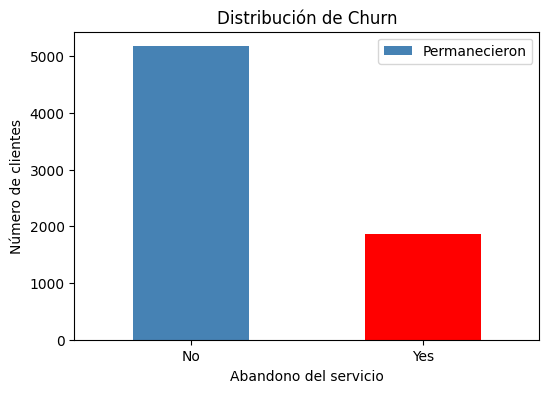

In [38]:
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'red'])
plt.title('Distribución de Churn')
plt.xlabel('Abandono del servicio')
plt.ylabel('Número de clientes')
plt.xticks(rotation=0)
plt.legend(['Permanecieron', 'Abandonaron'])
plt.show()

In [39]:
print(df['Churn'].value_counts())
print(f"\nPorcentaje de abandono: {df[df['Churn']=='Yes'].shape[0]/df.shape[0]*100:.2f}%")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentaje de abandono: 26.54%


#### Interpretación
De un total de 7043 clientes, 5174 permanecieron en el servicio (73.46%)
y 1869 abandonaron (26.54%). Esto indica que aproximadamente 1 de cada 4
clientes abandona el servicio, lo que representa un problema significativo
de retención para la empresa.

### Visualización 2 (Univariante): Distribución de Género
Analizamos la cantidad de clientes masculinos y femeninos en el dataset.

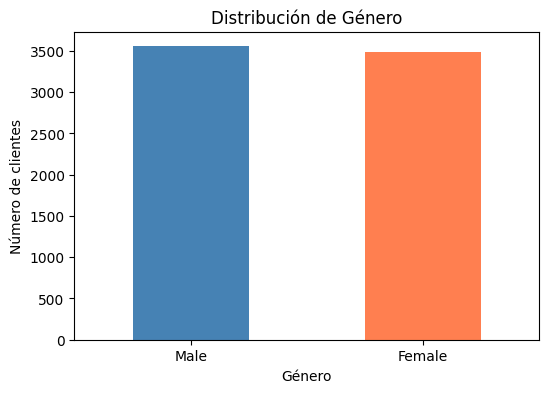

In [40]:
plt.figure(figsize=(6, 4))
df['gender'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Distribución de Género')
plt.xlabel('Género')
plt.ylabel('Número de clientes')
plt.xticks(rotation=0)
plt.show()

#### Interpretación
El gráfico muestra que hay una distribución bastante equilibrada entre
géneros, con una leve mayoría de clientes masculinos. Esto indica que
los servicios de telecomunicaciones son utilizados de forma similar
por ambos géneros.

### Visualización 3 (Univariante): Distribución de Antigüedad de Clientes
Analizamos cuánto tiempo llevan los clientes con el servicio.

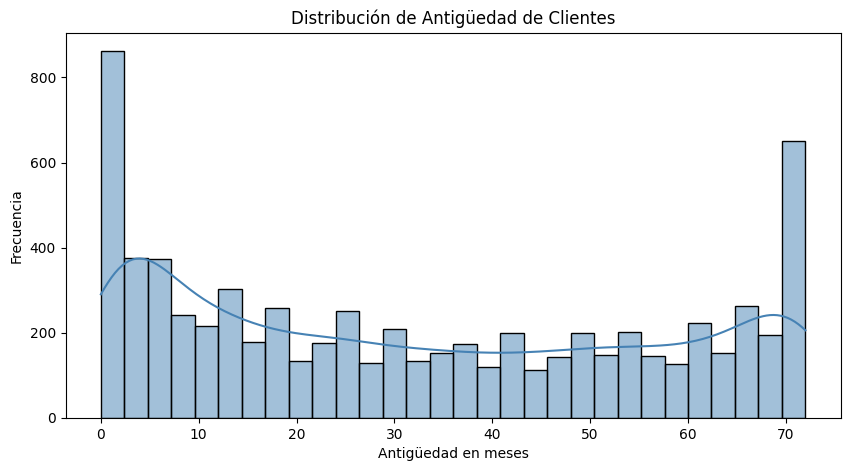

In [41]:
plt.figure(figsize=(10, 5))
sns.histplot(df['tenure'], kde=True, color='steelblue', bins=30)
plt.title('Distribución de Antigüedad de Clientes')
plt.xlabel('Antigüedad en meses')
plt.ylabel('Frecuencia')
plt.show()

In [42]:
# Dividir tenure en tres tercios
df['tenure_tercio'] = pd.cut(df['tenure'], bins=3, labels=['Nuevo (0-24 meses)', 'Intermedio (24-48 meses)', 'Antiguo (48-72 meses)'])

print(df['tenure_tercio'].value_counts().sort_index())


tenure_tercio
Nuevo (0-24 meses)          3210
Intermedio (24-48 meses)    1594
Antiguo (48-72 meses)       2239
Name: count, dtype: int64


#### Interpretación
El histograma muestra que la antigüedad de los clientes se concentra
en dos extremos: clientes muy nuevos y clientes muy antiguos.

- Clientes nuevos (0-24 meses): 3210 clientes (45.6%)
- Clientes intermedios (24-48 meses): 1594 clientes (22.6%)
- Clientes antiguos (48-72 meses): 2239 clientes (31.8%)

Esto sugiere que la empresa tiene dificultades para retener clientes
en el mediano plazo, ya que el grupo intermedio es el más pequeño.
Los clientes o se van temprano o se quedan por mucho tiempo.

### Visualización 4 (Multivariante): Antigüedad de Clientes por Soporte Técnico
Analizamos si los clientes que tienen soporte técnico tienden a
permanecer más tiempo en el servicio.

In [44]:
# Correlación entre tercio de antigüedad y soporte técnico
print("Distribución de Soporte Técnico por Tercio de Antigüedad:")
print(pd.crosstab(df['tenure_tercio'], df['TechSupport'], normalize='index').round(2) * 100)


Distribución de Soporte Técnico por Tercio de Antigüedad:
TechSupport                 No  No internet service   Yes
tenure_tercio                                            
Nuevo (0-24 meses)        61.0                 23.0  16.0
Intermedio (24-48 meses)  48.0                 21.0  31.0
Antiguo (48-72 meses)     33.0                 20.0  47.0


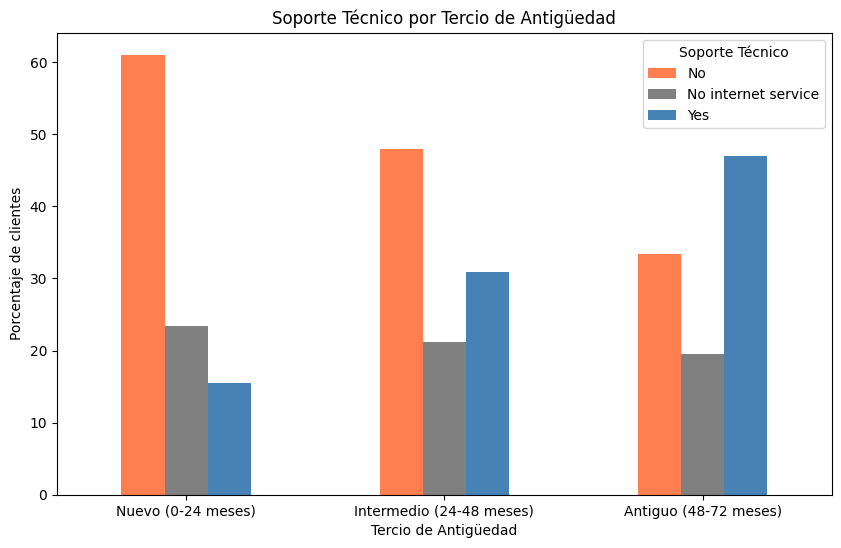

In [45]:
crosstab = pd.crosstab(df['tenure_tercio'], df['TechSupport'], normalize='index') * 100

crosstab.plot(kind='bar', figsize=(10, 6), color=['coral', 'gray', 'steelblue'])
plt.title('Soporte Técnico por Tercio de Antigüedad')
plt.xlabel('Tercio de Antigüedad')
plt.ylabel('Porcentaje de clientes')
plt.xticks(rotation=0)
plt.legend(title='Soporte Técnico')
plt.show()

#### Interpretación
Se observa una correlación clara entre antigüedad y soporte técnico.
- Clientes nuevos (0-24 meses): solo el 16% tiene soporte técnico
- Clientes intermedios (24-48 meses): el 31% tiene soporte técnico
- Clientes antiguos (48-72 meses): el 47% tiene soporte técnico

Esto sugiere que los clientes que contratan soporte técnico tienden
a permanecer más tiempo en el servicio, o que con el tiempo los
clientes van agregando más servicios a su contrato.

### Visualización 5 (Multivariante): Seguridad en Línea y Protección de Dispositivo por Género
Analizamos si existe diferencia entre géneros en el uso de servicios
de seguridad en línea y protección de dispositivo.

In [47]:
print("Seguridad en Línea por Género:")
print(pd.crosstab(df['gender'], df['OnlineSecurity']))

print("\nProtección de Dispositivo por Género:")
print(pd.crosstab(df['gender'], df['DeviceProtection']))

Seguridad en Línea por Género:
OnlineSecurity    No  No internet service   Yes
gender                                         
Female          1714                  747  1027
Male            1784                  779   992

Protección de Dispositivo por Género:
DeviceProtection    No  No internet service   Yes
gender                                           
Female            1538                  747  1203
Male              1557                  779  1219


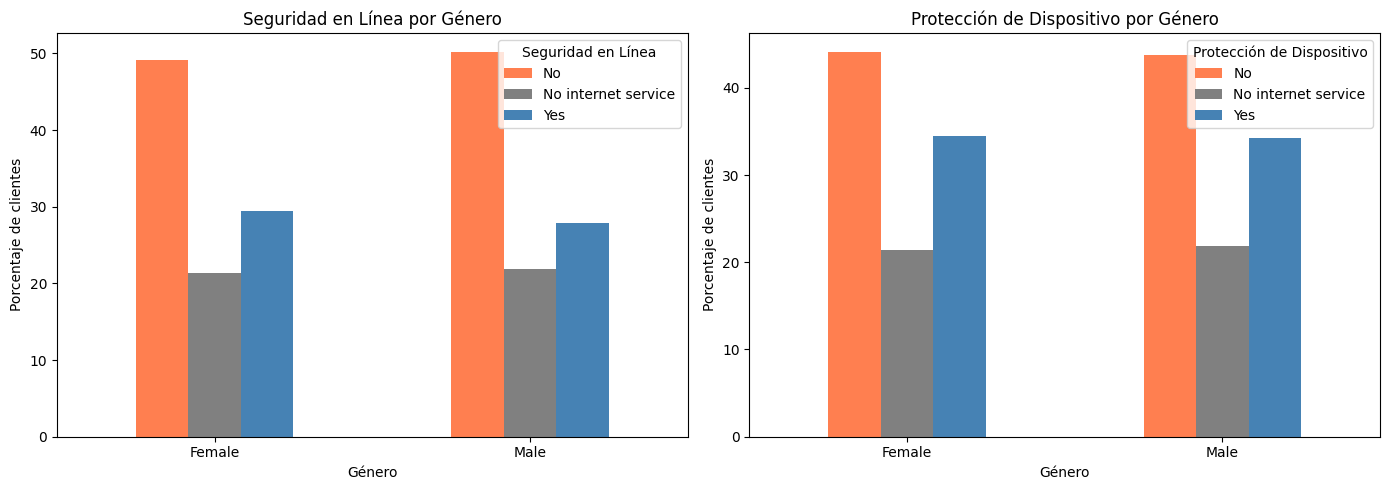

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Seguridad en línea por género
crosstab1 = pd.crosstab(df['gender'], df['OnlineSecurity'], normalize='index') * 100
crosstab1.plot(kind='bar', ax=axes[0], color=['coral', 'gray', 'steelblue'])
axes[0].set_title('Seguridad en Línea por Género')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Porcentaje de clientes')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Seguridad en Línea')

# Protección de dispositivo por género
crosstab2 = pd.crosstab(df['gender'], df['DeviceProtection'], normalize='index') * 100
crosstab2.plot(kind='bar', ax=axes[1], color=['coral', 'gray', 'steelblue'])
axes[1].set_title('Protección de Dispositivo por Género')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Porcentaje de clientes')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Protección de Dispositivo')

plt.tight_layout()
plt.show()

#### Interpretación
Los números muestran que no hay diferencia significativa entre géneros
en el uso de seguridad en línea y protección de dispositivo.
Ambos géneros tienen patrones de consumo muy similares.
Sin embargo la mayoría de clientes de ambos géneros NO contrata
estos servicios de seguridad

### Visualización 6 (Multivariante): Método de Pago por Churn
Analizamos si el método de pago tiene relación con el abandono del servicio.


In [48]:
print("Método de Pago por Churn:")
print(pd.crosstab(df['PaymentMethod'], df['Churn']))

Método de Pago por Churn:
Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308


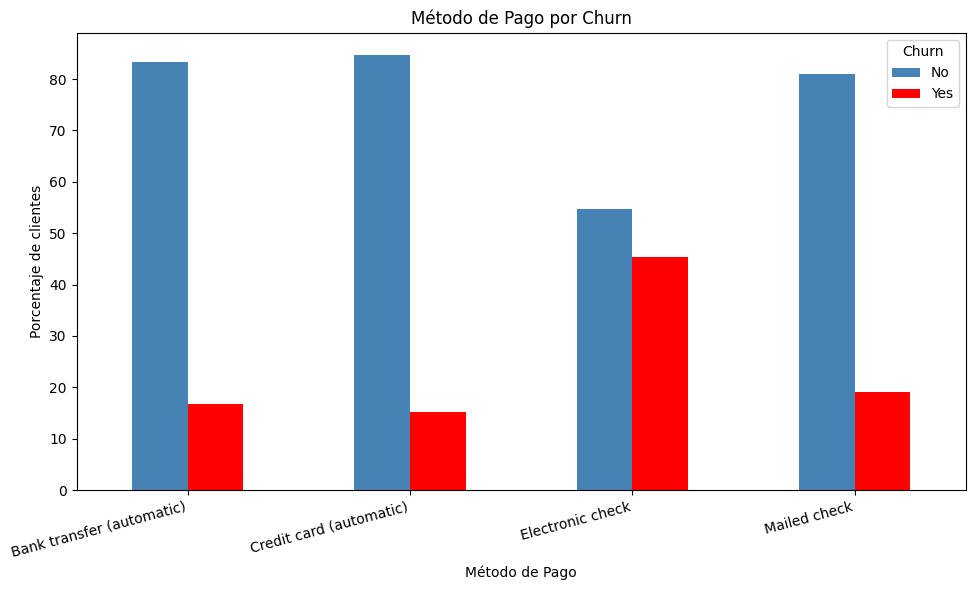

In [49]:
crosstab = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

crosstab.plot(kind='bar', figsize=(10, 6), color=['steelblue', 'red'])
plt.title('Método de Pago por Churn')
plt.xlabel('Método de Pago')
plt.ylabel('Porcentaje de clientes')
plt.xticks(rotation=15, ha='right')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()


#### Interpretación
Se observa una diferencia muy significativa en el abandono según
el método de pago:

- Cheque electrónico: 1071 abandonos dato critico
- Cheque por correo: 308 abandonos
- Transferencia bancaria automática: 258 abandonos
- Tarjeta de crédito automática: 232 abandonos

Los métodos de pago automáticos (transferencia bancaria y tarjeta
de crédito) tienen significativamente menos abandonos que los métodos
manuales. Esto sugiere que los clientes con pagos automáticos tienen
mayor compromiso con el servicio o menos obtaculos para pagar.

### Visualización 7 (Multivariante): Servicios de Telecomunicaciones por Género
Analizamos qué servicios usa más cada género.

In [50]:
print("Servicio Telefónico por Género:")
print(pd.crosstab(df['gender'], df['PhoneService']))

print("\nMúltiples Líneas por Género:")
print(pd.crosstab(df['gender'], df['MultipleLines']))

print("\nServicio de Internet por Género:")
print(pd.crosstab(df['gender'], df['InternetService']))

print("\nStreaming TV por Género:")
print(pd.crosstab(df['gender'], df['StreamingTV']))

print("\nStreaming Películas por Género:")
print(pd.crosstab(df['gender'], df['StreamingMovies']))

Servicio Telefónico por Género:
PhoneService   No   Yes
gender                 
Female        331  3157
Male          351  3204

Múltiples Líneas por Género:
MultipleLines    No  No phone service   Yes
gender                                     
Female         1671               331  1486
Male           1719               351  1485

Servicio de Internet por Género:
InternetService   DSL  Fiber optic   No
gender                                 
Female           1188         1553  747
Male             1233         1543  779

Streaming TV por Género:
StreamingTV    No  No internet service   Yes
gender                                      
Female       1386                  747  1355
Male         1424                  779  1352

Streaming Películas por Género:
StreamingMovies    No  No internet service   Yes
gender                                          
Female           1370                  747  1371
Male             1415                  779  1361


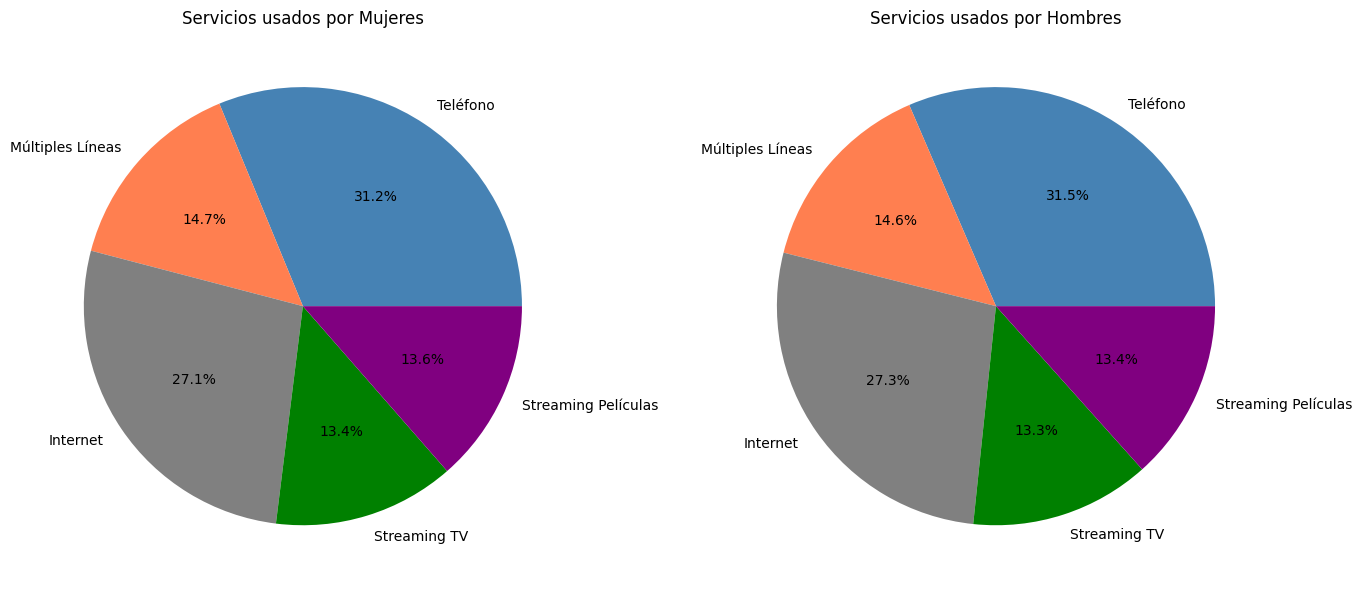

In [51]:
# Servicios con Yes para cada género
servicios = ['PhoneService', 'MultipleLines', 'InternetService', 'StreamingTV', 'StreamingMovies']

female_yes = [3157, 1486, 1553+1188, 1355, 1371]
male_yes = [3204, 1485, 1543+1233, 1352, 1361]
etiquetas = ['Teléfono', 'Múltiples Líneas', 'Internet', 'Streaming TV', 'Streaming Películas']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Torta mujeres
axes[0].pie(female_yes, labels=etiquetas, autopct='%1.1f%%',
            colors=['steelblue', 'coral', 'gray', 'green', 'purple'])
axes[0].set_title('Servicios usados por Mujeres')

# Torta hombres
axes[1].pie(male_yes, labels=etiquetas, autopct='%1.1f%%',
            colors=['steelblue', 'coral', 'gray', 'green', 'purple'])
axes[1].set_title('Servicios usados por Hombres')

plt.tight_layout()
plt.show()


#### Interpretación
Los gráficos de torta muestran que no existe una diferencia significativa
entre géneros en el consumo de servicios de telecomunicaciones.
Ambos géneros consumen los servicios en proporciones muy similares:
- El servicio telefónico es el más usado por ambos géneros
- El streaming de TV y películas tiene consumo casi idéntico
- Las múltiples líneas tienen uso similar en ambos géneros

Conclusión: el género no es un factor determinante en el consumo
de servicios de esta empresa de telecomunicaciones.

### Visualización 8 (Multivariante): Consumo de Servicios por Pareja
Analizamos si los clientes que tienen pareja consumen más servicios.

In [52]:
print("Servicios por Pareja:")
print(pd.crosstab(df['Partner'], df['PhoneService']))
print(pd.crosstab(df['Partner'], df['InternetService']))
print(pd.crosstab(df['Partner'], df['StreamingTV']))
print(pd.crosstab(df['Partner'], df['StreamingMovies']))

Servicios por Pareja:
PhoneService   No   Yes
Partner                
No            371  3270
Yes           311  3091
InternetService   DSL  Fiber optic   No
Partner                                
No               1253         1600  788
Yes              1168         1496  738
StreamingTV    No  No internet service   Yes
Partner                                     
No           1667                  788  1186
Yes          1143                  738  1521
StreamingMovies    No  No internet service   Yes
Partner                                         
No               1642                  788  1211
Yes              1143                  738  1521


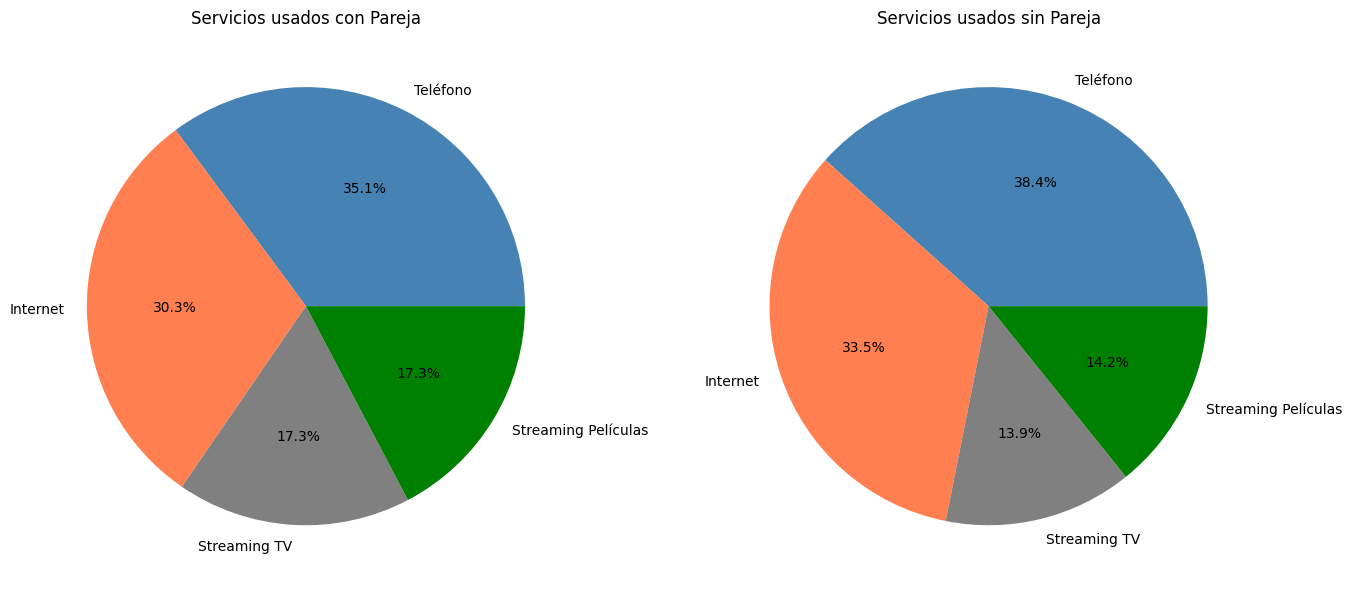

In [53]:
partner_yes = [3091, 1496+1168, 1521, 1521]
partner_no = [3270, 1600+1253, 1186, 1211]
etiquetas = ['Teléfono', 'Internet', 'Streaming TV', 'Streaming Películas']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(partner_yes, labels=etiquetas, autopct='%1.1f%%',
            colors=['steelblue', 'coral', 'gray', 'green'])
axes[0].set_title('Servicios usados con Pareja')

axes[1].pie(partner_no, labels=etiquetas, autopct='%1.1f%%',
            colors=['steelblue', 'coral', 'gray', 'green'])
axes[1].set_title('Servicios usados sin Pareja')

plt.tight_layout()
plt.show()


#### Interpretación
Los gráficos muestran diferencias  entre clientes con y sin pareja:

- Streaming TV y Streaming Películas: los clientes CON pareja consumen
  más estos servicios, lo cual tiene sentido ya que el contenido
  audiovisual se disfruta más en compañía.
  
- Teléfono e Internet: los clientes SIN pareja tienen mayor consumo,
  posiblemente porque dependen más de la conectividad para comunicarse
  con otros.

Conclusión: el estado de pareja influye en el tipo de servicios que
consume el cliente. Los clientes con pareja prefieren entretenimiento
y los sin pareja priorizan comunicación y conectividad.

#### Interpretación
Los gráficos muestran diferencias interesantes entre clientes con y sin pareja:

- Streaming TV y Streaming Películas: los clientes CON pareja consumen
  más estos servicios, lo cual tiene sentido ya que el contenido
  audiovisual se disfruta más en compañía.
  
- Teléfono e Internet: los clientes SIN pareja tienen mayor consumo,
  posiblemente porque dependen más de la conectividad para comunicarse
  con otros.

Conclusión: el estado de pareja influye en el tipo de servicios que
consume el cliente. Los clientes con pareja prefieren entretenimiento
y los sin pareja priorizan comunicación y conectividad.

### Visualización 9 (Multivariante): Consumo de Servicios por Personas Mayores
Analizamos si las personas mayores consumen los servicios de manera diferente.

In [54]:
print("Servicios por SeniorCitizen:")
print(pd.crosstab(df['SeniorCitizen'], df['PhoneService']))
print(pd.crosstab(df['SeniorCitizen'], df['InternetService']))
print(pd.crosstab(df['SeniorCitizen'], df['StreamingTV']))
print(pd.crosstab(df['SeniorCitizen'], df['StreamingMovies']))

Servicios por SeniorCitizen:
PhoneService    No   Yes
SeniorCitizen           
No             578  5323
Yes            104  1038
InternetService   DSL  Fiber optic    No
SeniorCitizen                           
No               2162         2265  1474
Yes               259          831    52
StreamingTV      No  No internet service   Yes
SeniorCitizen                                 
No             2292                 1474  2135
Yes             518                   52   572
StreamingMovies    No  No internet service   Yes
SeniorCitizen                                   
No               2290                 1474  2137
Yes               495                   52   595


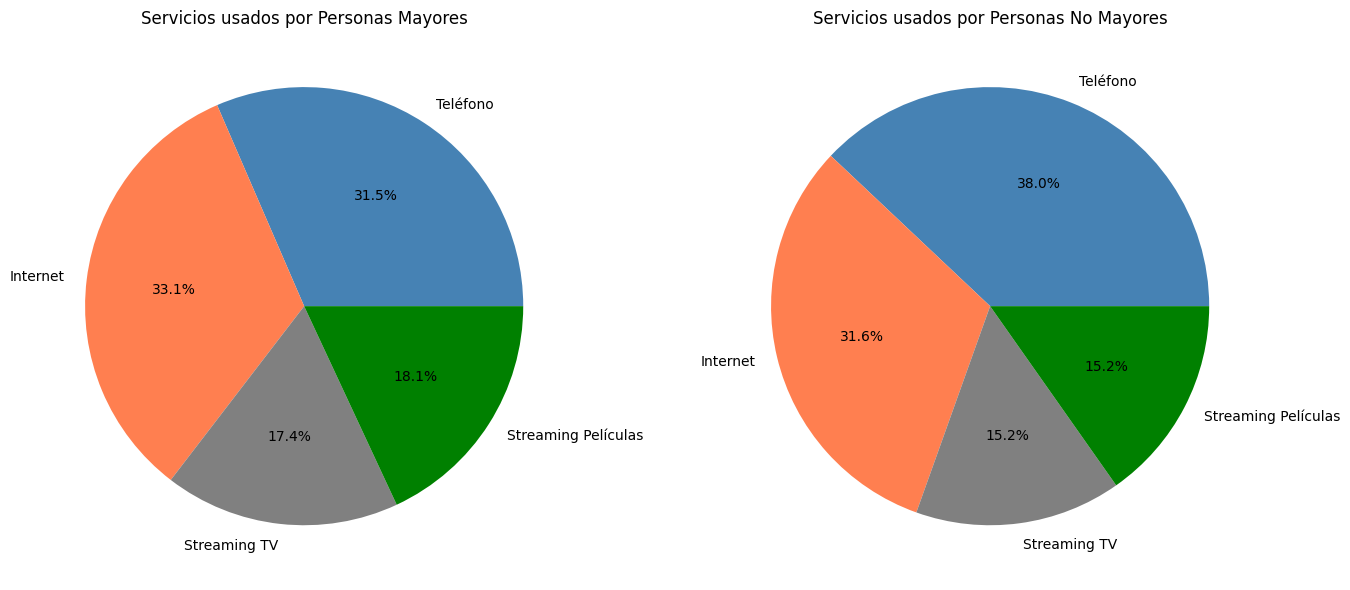

In [55]:
senior_yes = [1038, 831+259, 572, 595]
senior_no = [5323, 2265+2162, 2135, 2137]
etiquetas = ['Teléfono', 'Internet', 'Streaming TV', 'Streaming Películas']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(senior_yes, labels=etiquetas, autopct='%1.1f%%',
            colors=['steelblue', 'coral', 'gray', 'green'])
axes[0].set_title('Servicios usados por Personas Mayores')

axes[1].pie(senior_no, labels=etiquetas, autopct='%1.1f%%',
            colors=['steelblue', 'coral', 'gray', 'green'])
axes[1].set_title('Servicios usados por Personas No Mayores')

plt.tight_layout()
plt.show()

Conclusión clave:
Las personas mayores proporcionalmente consumen más streaming y más fibra óptica que las no mayores. Esto es interesante porque contradice el estereotipo de que las personas mayores usan menos tecnología.

### Visualización 10 (Multivariante): Matriz de Correlación
Analizamos la correlación entre las variables numéricas del dataset:
tenure, MonthlyCharges y TotalCharges.

In [57]:
print("Correlación entre variables numéricas:")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr())

Correlación entre variables numéricas:
                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.247900      0.826178
MonthlyCharges  0.247900        1.000000      0.651174
TotalCharges    0.826178        0.651174      1.000000


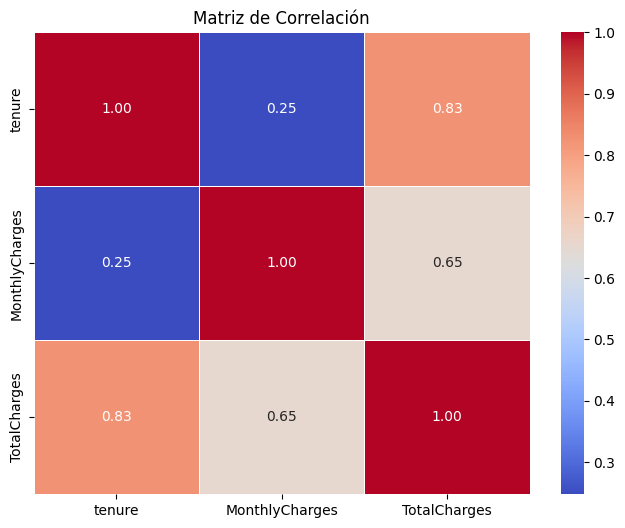

In [56]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

**Correlaciones entre Variables Numéricas**
- tenure y TotalCharges: 0.83 — correlación muy alta y lógica.
  A más tiempo como cliente, más cargos totales acumula.
- MonthlyCharges y TotalCharges: 0.65 — correlación moderada-alta.
  A mayor cargo mensual, mayor cargo total acumulado.
- tenure y MonthlyCharges: 0.25 — correlación baja.
  La antigüedad del cliente no determina cuánto paga mensualmente.

## Informe Final: Análisis de Rotación de Clientes en Telecomunicaciones

### Hallazgos Principales

**Abandono de clientes (Churn)**
- 26.54% de los clientes abandonó el servicio (1869 de 7043)
- Los clientes que pagan con cheque electrónico abandonan significativamente
  más que los que usan métodos automáticos
- Los métodos de pago automáticos están asociados a mayor retención

**Antigüedad**
- 45.6% son clientes nuevos (0-24 meses)
- 22.6% son clientes intermedios (24-48 meses)
- 31.8% son clientes antiguos (48-72 meses)
- Los clientes con soporte técnico tienden a permanecer más tiempo

**Género**
- Distribución equilibrada con leve mayoría masculina
- No hay diferencias significativas en consumo de servicios por género
- El género no es un factor determinante en el abandono

**Pareja**
- Clientes con pareja consumen más streaming de TV y películas
- Clientes sin pareja consumen más servicios de telefonía e internet

**Personas Mayores**
- Representan el 16% del total (1142 clientes)
- Proporcionalmente consumen más fibra óptica y streaming
- Contradicen el estereotipo de menor uso tecnológico

**Correlaciones**
- Alta correlación entre antigüedad y cargos totales (0.83)
- Correlación moderada entre cargos mensuales y totales (0.65)
- Baja correlación entre antigüedad y cargos mensuales (0.25)

### Conclusión General
El principal factor de riesgo de abandono es el método de pago,
especialmente el cheque electrónico. Se recomienda incentivar
a los clientes a migrar a métodos de pago automáticos y enfocarse
en retener a los clientes en su primer año ya que es cuando
mayor riesgo de abandono existe.